This script is to construct a simple underground model, that contains a mesh, with artificial dataset of a ground property (e.g. stiffness) and scale of fluctuation. 

In [1]:
import os
from pathlib import Path
import pyvista as pv
import numpy as np
import vtk
from vtk.util.numpy_support import numpy_to_vtk
import ogs as ogs
import generate_random_field

In [2]:
out_dir = Path(os.environ.get("OGS_TESTRUNNER_OUT_DIR", "_out"))
if not out_dir.exists():
    out_dir.mkdir(parents=True)

os.chdir(out_dir)

In [3]:
import Mesh_settings

# ---- Parameters ----
# Define parameters for the mesh and random field generation
lx, ly,lz= Mesh_settings.lx,  Mesh_settings.ly, Mesh_settings.lz
ex, ey,ez = Mesh_settings.ex, Mesh_settings.ey, Mesh_settings.ez
nx, ny, nz = ex+1,ey+1, ez+1
scales = (22, 1.17) 
acf_type="exponential" 
distribution="lognormal"  
cov=0.3
layers = Mesh_settings.layers

file = 'empty_mesh.vtu'

In [4]:
if ey > 1:  # 3D case
    ogs.cli.generateStructuredMesh(o= file ,e='hex',lx=lx,ly=ly,lz=lz, nx=ex,ny=ey,nz=ez,oz=-lz)
    #subprocess.run(f"generateStructuredMesh -e hex -o {file} --lx {lx} --ly {ly} --lz {lz} --nx {ex} --ny {ey} --nz {ez} --oz {-lz}") 

else:  # 2D case
    ogs.cli.generateStructuredMesh(o= file ,e='quad',lx=lx,ly=lz, nx=ex,ny=ez,oy=-lz)
    #subprocess.run(f"generateStructuredMesh -e quad -o {file} --lx {lx} --ly {lz} --nx {ex} --ny {ez} --oy {-lz}") 

In [5]:
#subprocess.run(f"identifySubdomains -m {file} -s 1e-6 -f {file}")
ogs.cli.identifySubdomains (m = file, s = '1e-6', f= file)

0

In [6]:
# pyvista settings
pv.set_plot_theme("document")
pv.set_jupyter_backend("static")

Here we read the mesh file.

In [7]:
mesh = pv.read(file) # file
reader = vtk.vtkXMLUnstructuredGridReader()
reader.SetFileName(file) # file
reader.Update()  # Needed because of GetScalarRange
reader_data = reader.GetOutput()

In [8]:
# ---- Generate Random Field ----
# Generate a random field with increasing stiffness and variance with depth
trend = generate_random_field.formula_derived_layer(lz, nz, layers)

if ex ==1 and ey==1: # 1D case
    field = generate_random_field.stepwise_cmd_1d_random_field(
        nz, lz,
        scales[1], # Correlation scales
        cov,
        trend,  # Stiffness mean trend
        acf_type = acf_type,  # Type of autocorrelation function
        distribution = distribution  # Lognormal distribution for stiffness
    )

    stiff_field = generate_random_field.convert_to_element_field_1d(field, ez)
    stiff_field=np.flip(stiff_field, axis=0)

else:
    field = generate_random_field.stepwise_cmd_3d_random_field(   
        nx, ny, nz,  # Dimensions of the field
        lx, ly, lz,
        (scales[0], scales[0], scales[1]),  # Correlation scales
        cov,
        trend,  # Stiffness mean trend
        acf_type = acf_type,  # Type of autocorrelation function
        distribution = distribution  # Lognormal distribution for stiffness
    ) #3D case
    
    # ---- Convert to Element Field ----
    # Convert node-based field to element-based field (averaged values for visualization)
    
    element_field = generate_random_field.convert_to_element_field(field, ex, ey, ez) # to convert node-based RF to element-based RF
    #element_field = field[1:,1:,1:] # without conversion
    
    if ey==1:
        stiff_field = element_field[:, 0, :] # Extract the 2D stiffness field for plotting
        stiff_field=np.flip(stiff_field, axis=1)
    else:
        stiff_field = element_field[:, :, :]  
        stiff_field=np.flip(stiff_field, axis=2)

c:\Users\glori\OneDrive\Onenote\Python Scripts\model\generate_random_field.py:138: RuntimeWarning: divide by zero encountered in log
  mean_z = np.log(stiffness_modulus_z) - 0.5 * np.log(1 + cov**2)


We add the above result into the mesh structure, and write a new mesh file.

In [9]:
# Add Stiffness to vtu

stiffness_1D_array =  stiff_field.flatten('F')
stiffness_vtk = numpy_to_vtk(stiffness_1D_array)
stiffness_vtk.SetName('Stiffness')
reader_data.GetCellData().AddArray(stiffness_vtk)


dz = lz / ez  # Element height
depths = np.linspace(-lz+(dz/2), -(dz/2), ez)  # Element center depths
#depths = np.linspace(-lz+dz, -dz+dz, ez)

# Add Density, nu, porosity to vtu
density_array = np.zeros(ez, dtype=float)
nu_array = np.zeros(ez, dtype=float)
phi_array = np.zeros(ez, dtype=float)
initial_stress_xx_array = np.zeros(ez, dtype=float)
initial_stress_yy_array = np.zeros(ez, dtype=float)

# Constants
initial_GWT = -50  # Ground water table at -50 m
g = -9.81  # gravity

for i, depth in enumerate(depths):  # depths from -59.5 to -0.5
    sigma_yy = 0
    nu_at_depth = 0

    for z_start, z_end, v, w, density, nu, phi in layers:
        layer_top = -z_start      
        layer_bottom = -z_end     

        # Skip if the layer is entirely below the depth (no contribution)
        if layer_top <= depth:
            continue

        # Only the part of the layer that lies above the current depth contributes
        contrib_top = layer_top  # shallower
        contrib_bottom = max(layer_bottom, depth)  # clip at depth
        thickness = contrib_top - contrib_bottom

        if thickness <= 0:
            continue

        # Handle water table effects
        if contrib_top >= initial_GWT and contrib_bottom >= initial_GWT:
            gamma = (1 - phi) * density * g
            sigma_yy += gamma * thickness

        elif contrib_top < initial_GWT and contrib_bottom < initial_GWT:
            gamma = ((1 - phi) * density + phi * 1000) * g
            sigma_yy += gamma * thickness

        else:  # crosses GWT
            above_thickness = contrib_top - initial_GWT
            below_thickness = initial_GWT - contrib_bottom

            gamma_above = (1 - phi) * density * g
            gamma_below = ((1 - phi) * density + phi * 1000) * g

            sigma_yy += gamma_above * above_thickness
            sigma_yy += gamma_below * below_thickness

        # Set properties at this depth
        if layer_bottom <= depth <= layer_top:
            density_array[i] = density
            nu_array[i] = nu
            phi_array[i] = phi
            nu_at_depth = nu

    # Compute horizontal stress
    sigma_xx = nu_at_depth / (1 - nu_at_depth) * sigma_yy

    initial_stress_yy_array[i] = sigma_yy
    initial_stress_xx_array[i] = sigma_xx


density_1D_array = np.repeat(density_array, ex*ey)
nu_1D_array = np.repeat(nu_array, ex*ey)
phi_1D_array = np.repeat(phi_array, ex*ey)
initial_stress_xx_1D_array = np.repeat(initial_stress_xx_array, ex*ey)
initial_stress_yy_1D_array = np.repeat(initial_stress_yy_array, ex*ey)

if ey==1:
    initial_stress_1D_array = np.column_stack((
        initial_stress_xx_1D_array,
        initial_stress_yy_1D_array,
        initial_stress_xx_1D_array,
        np.zeros_like(initial_stress_xx_1D_array)
    ))
else:
    initial_stress_1D_array = np.column_stack((
    initial_stress_xx_1D_array,
    initial_stress_xx_1D_array,
    initial_stress_yy_1D_array,
    np.zeros_like(initial_stress_xx_1D_array),
    np.zeros_like(initial_stress_xx_1D_array),
    np.zeros_like(initial_stress_xx_1D_array)
    ))


density_vtk = numpy_to_vtk(density_1D_array)
nu_vtk = numpy_to_vtk(nu_1D_array)
phi_vtk = numpy_to_vtk(phi_1D_array)
initial_stress_vtk = numpy_to_vtk(initial_stress_1D_array)

density_vtk.SetName('Density')
nu_vtk.SetName('nu')
phi_vtk.SetName('Porosity')
initial_stress_vtk.SetName('initial_stress')

reader_data.GetCellData().AddArray(density_vtk)
reader_data.GetCellData().AddArray(nu_vtk)
reader_data.GetCellData().AddArray(phi_vtk)
reader_data.GetCellData().AddArray(initial_stress_vtk)

# write all parameters to the vtu
writer = vtk.vtkXMLUnstructuredGridWriter()
writer.SetInputData(reader_data)
writer.SetFileName("domain_with_stiffness.vtu")
writer.Write()

1

We read and plot the new mesh file. 

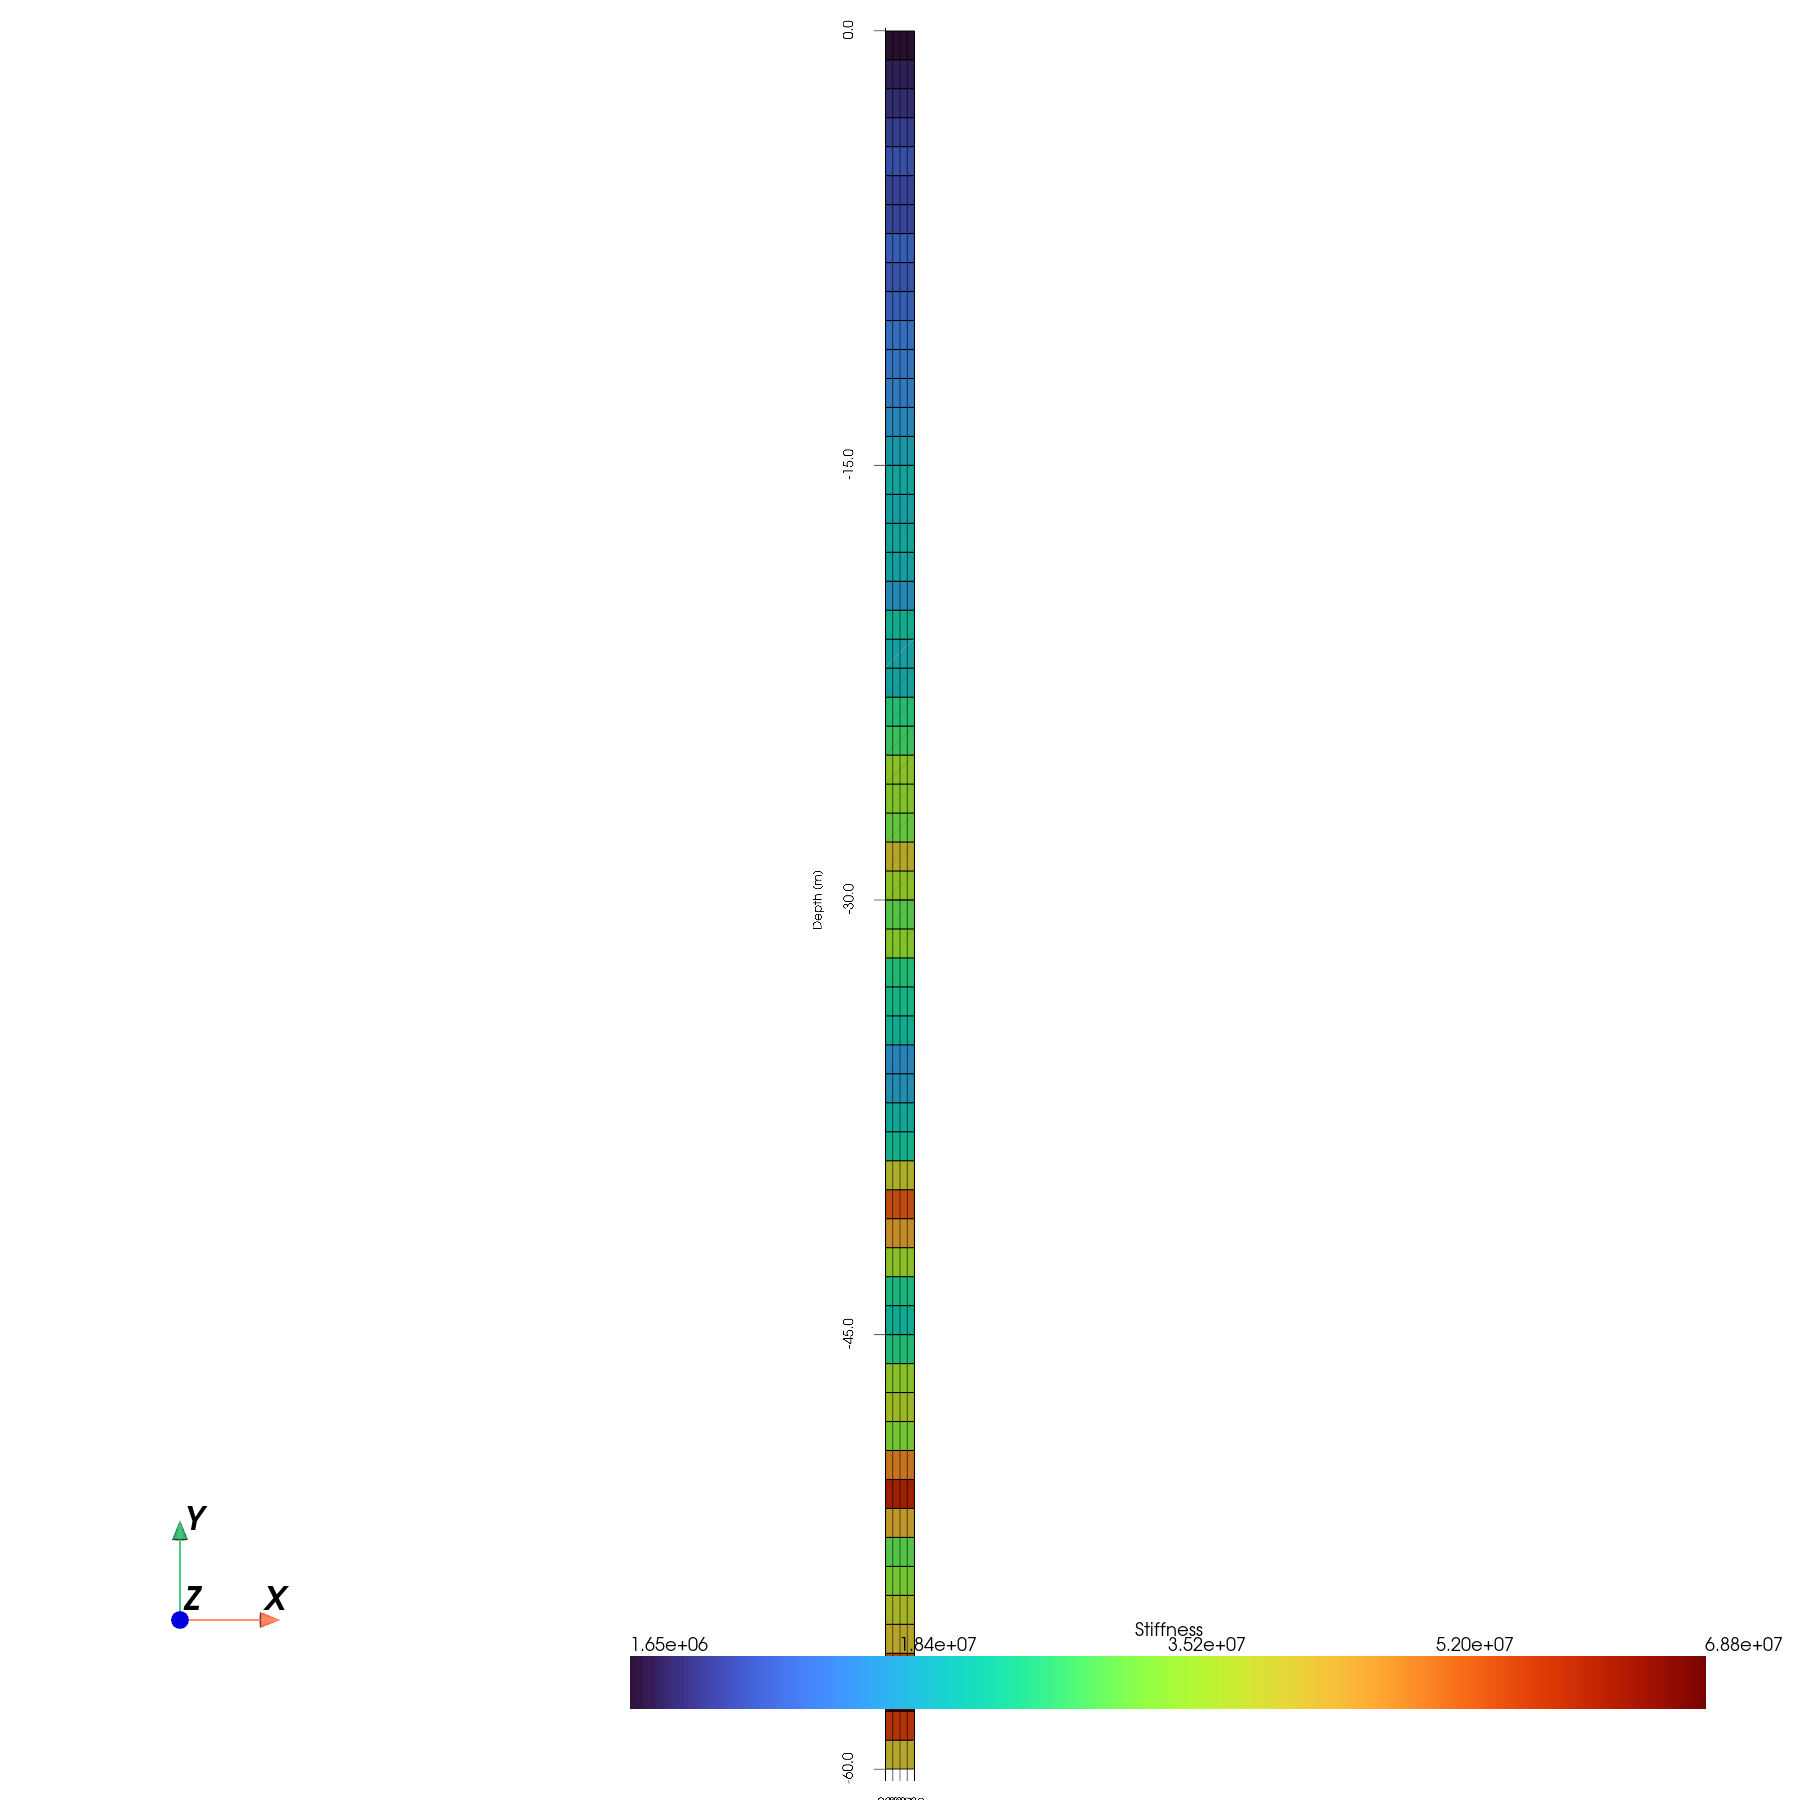

In [10]:
new_mesh = pv.read("domain_with_stiffness.vtu")

pl = pv.Plotter()

pl.add_mesh(new_mesh,  scalars = "Stiffness", show_edges=True, cmap="turbo")
if ey==1:    
    pl.view_xy()
pl.add_axes()
pl.window_size = [1800, 1800]

pl.show_grid(ytitle='Depth (m)', font_family ='arial', font_size=10, bold=False)

pl.show()


Here we draw a graph to visualize the change of stiffness parameter over depth. 

This is a graph taking the mid x-axis.

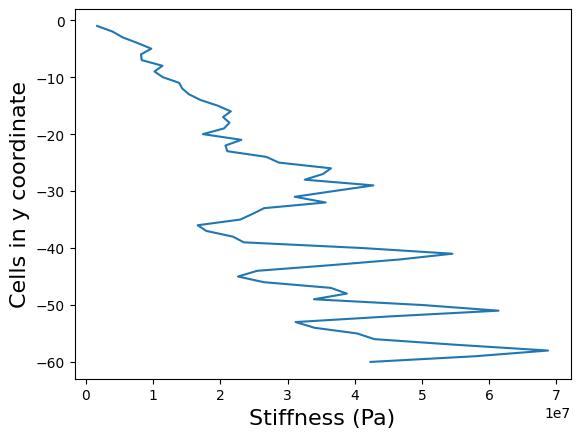

In [11]:
import matplotlib.pyplot as plt
import numpy as np

if ex == 1:
    xpoints = stiff_field[:]  
elif ey == 1:
    xpoints = stiff_field[ex // 2, :]  
else:
    xpoints = stiff_field[ex // 2, ey//2, :]  

ypoints = np.arange ( -ez, 0, 1)  #ez

plt.xlabel('Stiffness (Pa)', fontsize=16)
plt.ylabel('Cells in y coordinate', fontsize=16)

plt.plot(xpoints, ypoints)
plt.show()

This is a graph taking the mean of the x axis.

In [12]:
# xpoints = np.mean(stiff_field, axis=0)   # total_rf  to check detrended RF, stiffness to check trend
# #xpoints = np.flip(trend[1:])
# ypoints = np.arange ( -ez, 0, 1)

# plt.xlabel('Stiffness (Pa)', fontsize=16)
# plt.ylabel('Element index in z direction', fontsize=16)

# plt.plot(xpoints, ypoints)
# plt.show()

In [13]:
os.chdir("..")

In [14]:
stiff_field.shape

(60,)

In [15]:
stiff_field_inverted=stiff_field[::-1][10:99]  #[5:49]  #[10:99]
stiff_field_inverted


array([13875961.33679122, 14331077.24902485, 15316421.49934217,
       17028114.24504205, 19595986.93501858, 21552279.54625054,
       20392571.93559235, 21358149.74599767, 20539550.10512713,
       17401033.62110103, 23124504.11046203, 20757593.59559119,
       21031804.59087556, 26863273.80030121, 28701947.84577478,
       36457039.94304906, 35273817.68708117, 32554715.70086789,
       42774859.27520664, 36876955.57268598, 31074687.1786456 ,
       35660683.00407298, 26514228.74970356, 24799493.9935892 ,
       22968591.87462691, 16625523.85425021, 17910233.75697424,
       21861761.72792567, 23483522.95471272, 41088987.90202187,
       54531344.18092749, 46771939.40728598, 36530045.83237176,
       25485961.94672047, 22621785.61092919, 26483536.38873125,
       36446327.76369368, 38822405.1531592 , 33919264.96262577,
       49952920.88691483, 61388894.73481292, 45329882.2761827 ,
       31189989.65397765, 33996160.98622149, 40359140.15131284,
       42916292.28641749, 55198875.95532